In [1]:
import numpy as np
import random

import pickle as pkl
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainwidemap import bwm_query, bwm_units, load_good_units, load_trials_and_mask
from tqdm import tqdm
from one.api import ONE
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ibl_info.utils import check_config
from ibl_info.rsa_regression import ideal_rsa_matrices, run_rsa_regression, simpler_rsa_matrices
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
from ibl_info.manifold import (
    plot_pcas_separate_decomposition,
    plot_pcas_separate_decomposition_adapted,
)
import warnings

warnings.filterwarnings("ignore")

## Only correct trajectories

In [ ]:
with open("../data/generated/manifold/bwm_accumulated_data.pkl", "rb") as f:
    dx = pkl.load(f)

In [ ]:
# normalization = False
# model_vectors, model_names = ideal_rsa_matrices()

In [ ]:
plot_pcas_separate_decomposition_adapted(
    dx, "LGd", ["Left Con", "Left Incon", "Right Con", "Right Incon"]
)

In [ ]:
# now we fit kernels

In [ ]:
model_vectors, model_names, model_matrices = simpler_rsa_matrices()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=3, sharex=True, sharey=True)

for idx, (name, array) in enumerate(model_matrices.items()):
    cond_labels = ["Left_Con", "Left_Incon", "Right_Con", "Right_Incon"]
    if idx == 2:
        cbar = True
    else:
        cbar = False
    sns.heatmap(
        array,
        ax=ax[idx],
        linewidths=0.3,
        square=True,
        xticklabels=cond_labels,
        yticklabels=cond_labels,
        cbar=False,
    )
    ax[idx].set_title(f"{name}")

In [ ]:
results_correct_only = run_rsa_regression(
    dx, model_vectors=model_vectors, model_names=model_names, conditions=4, model_type="NNLS"
)

In [ ]:
from ibl_info.rsa_regression import plot_rsa_dynamics

In [ ]:
plot_rsa_dynamics(results_correct_only, "GRN", model_names)

In [ ]:
for k in results_correct_only.keys():
    plot_rsa_dynamics(results_correct_only, k, model_names)

In [ ]:
from ibl_info.rsa_regression import plot_rsa_summary_bars

In [ ]:
df = plot_rsa_summary_bars(results_correct_only, model_names)

## Manifold, all trials


In [ ]:
with open("../data/generated/manifold/bwm_manifold_8conditions.pkl", "rb") as f:
    dx_all = pkl.load(f)

In [ ]:
model_vectors, model_names, model_matrices = ideal_rsa_matrices()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=5, sharex=True, sharey=True)
cond_labels = [
    "L_Cong_Corr",
    "L_Cong_Err ",
    "L_Inc_Corr ",
    "L_Inc_Err  ",
    "R_Cong_Corr",
    "R_Cong_Err ",
    "R_Inc_Corr ",
    "R_Inc_Err  ",
]
for idx, (name, array) in enumerate(model_matrices.items()):

    if idx == 2:
        cbar = True
    else:
        cbar = False
    sns.heatmap(
        array,
        ax=ax[idx],
        linewidths=0.3,
        square=True,
        xticklabels=cond_labels,
        yticklabels=cond_labels,
        cbar=False,
    )
    ax[idx].set_title(f"{name}")

In [ ]:
model_names

In [ ]:
results_all_without_outcome = run_rsa_regression(
    dx_all, model_vectors, ["Choice", "Prior", "Congruence", "Stimulus"], model_type="NNLS"
)

In [ ]:
results_all = run_rsa_regression(dx_all, model_vectors, model_names, model_type="NNLS")

In [ ]:
for k in results_correct_only.keys():
    plot_rsa_dynamics(results_all, k, model_names)

In [ ]:
plot_rsa_summary_bars(results_all, model_names)

In [ ]:
plot_rsa_summary_bars(results_all_without_outcome, ["Choice", "Prior", "Congruence", "Stimulus"])

### Difficulty 

In [39]:
with open("../data/generated/manifold/bwm_accumulated_data_correct_difficulty.pkl", "rb") as f:
    dx_all_difficulty = pkl.load(f)

In [44]:
conds = [
    "L_Cong_Easy_Corr",
    "R_Incong_Easy_Corr",
    "R_Cong_Easy_Corr",
    "L_Incong_Easy_Corr",
    "L_Cong_Hard_Corr",
    "R_Incong_Hard_Corr",
    "R_Cong_Hard_Corr",
    "L_Incong_Hard_Corr",
]


--- Visualizing Region: PRNr ---


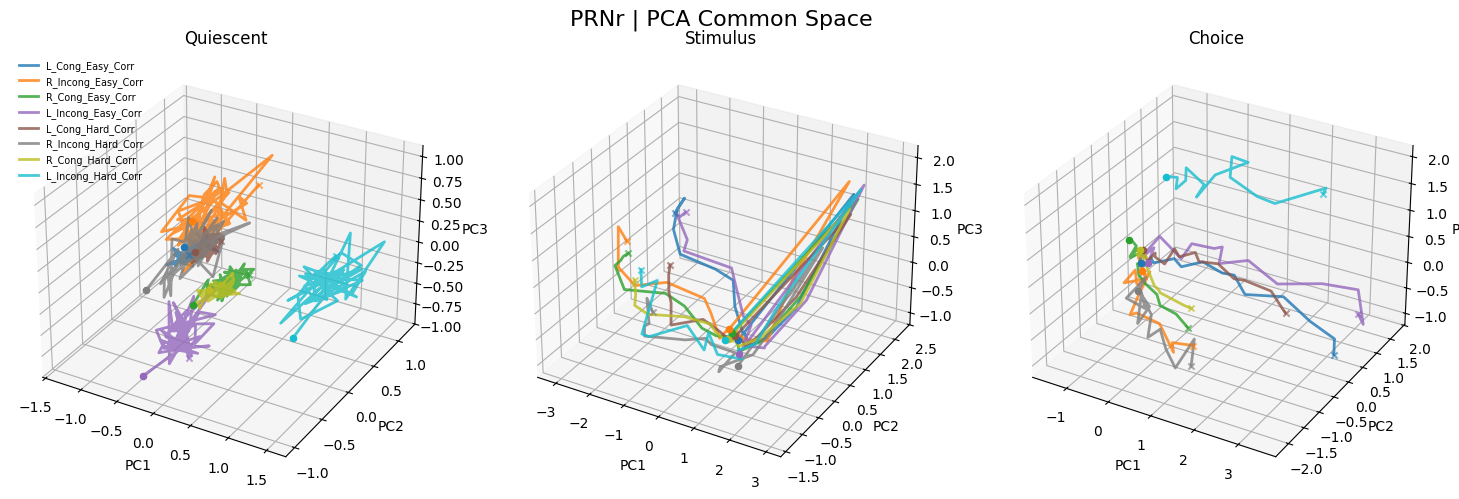

In [50]:
plot_pcas_separate_decomposition_adapted(dx_all_difficulty, region="PRNr", cond_names=conds)

### Time Statistics 

In [56]:
def compute_avg_reaction_times(trial_df):
    """
    Computes average reaction times for 8 conditions:
    Stimulus-side x Congruency x Correct/Incorrect

    Parameters:
    trial_df (pd.DataFrame): DataFrame containing trial data with columns:
                             'contrastRight', 'contrastLeft', 'probabilityLeft',
                             'firstMovement_times', 'stimOn_times', 'feedbackType'

    Returns:
    pd.DataFrame: A DataFrame with the 8 conditions and their average reaction times.
    """
    # Create a copy to avoid SettingWithCopyWarning
    df = trial_df.copy()

    # 1. Define Reaction Time
    # RT = First Movement - Stimulus Onset
    df["rt"] = df["firstMovement_times"] - df["stimOn_times"]

    # Filter for valid reaction times (exclude anticipatory movements <= 0)
    df = df[df["rt"] > 0]

    # 2. Define Stimulus Side
    # Calculate signed contrast (Right - Left). NaNs are treated as 0.
    df["contrastRight"] = df["contrastRight"].fillna(0)
    df["contrastLeft"] = df["contrastLeft"].fillna(0)
    df["signed_contrast"] = df["contrastRight"] - df["contrastLeft"]

    # Side is determined by the sign of the contrast.
    # Exclude 0 contrast trials as they have no side.
    df = df[df["signed_contrast"] != 0]
    df["side"] = np.where(df["signed_contrast"] > 0, "Right", "Left")

    # 3. Define Congruency
    # Exclude neutral blocks (probabilityLeft == 0.5) to strictly define congruency
    df = df[df["probabilityLeft"] != 0.5]

    # Congruent: (Stim Left & High Prob Left) OR (Stim Right & Low Prob Left)
    # Incongruent: (Stim Left & Low Prob Left) OR (Stim Right & High Prob Left)
    conditions = [
        (df["side"] == "Left") & (df["probabilityLeft"] > 0.5),
        (df["side"] == "Right") & (df["probabilityLeft"] < 0.5),
    ]
    df["congruency"] = np.select(conditions, ["Congruent", "Congruent"], default="Incongruent")

    # 4. Define Correct/Incorrect
    # feedbackType 1 is Correct, -1 is Incorrect
    df["outcome"] = df["feedbackType"].map({1: "Correct", -1: "Incorrect"})

    # 5. Group and Compute Mean
    group_cols = ["side", "congruency", "outcome"]
    stats = df.groupby(group_cols)["rt"].agg(avg_rt="mean", trial_count="count").reset_index()

    return stats

In [53]:
tx = pd.read_csv("../data/external/sample_data.csv")

In [57]:
compute_avg_reaction_times(tx)

,side,congruency,outcome,avg_rt,trial_count
0,Left,Congruent,Correct,0.123000,118
1,Left,Congruent,Incorrect,0.018267,1
2,Left,Incongruent,Correct,0.138069,33
3,Left,Incongruent,Incorrect,0.010500,1
4,Right,Congruent,Correct,0.530897,146
5,Right,Congruent,Incorrect,4.237591,18
6,Right,Incongruent,Correct,0.395537,30
7,Right,Incongruent,Incorrect,0.028111,3


In [69]:
from ibl_info.manifold import MY_REGIONS


one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    password="international",
    silent=True,
    username="intbrainlab",
)
print("Querying BWM Units...")

units_df = bwm_units(one)
relevant_pids = units_df[units_df["Beryl"].isin(MY_REGIONS)]["pid"].unique()

bwm_df = bwm_query(one)
subset_df = bwm_df[bwm_df["pid"].isin(relevant_pids)]

Querying BWM Units...
Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01
Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [71]:
subset_df["eid"].unique()

array(['6713a4a7-faed-4df2-acab-ee4e63326f8d',
       '56956777-dca5-468c-87cb-78150432cc57',
       'b182b754-3c3e-4942-8144-6ee790926b58',
       'a8a8af78-16de-4841-ab07-fde4b5281a03',
       '032ffcdf-7692-40b3-b9ff-8def1fc18b2e',
       '8c33abef-3d3e-4d42-9f27-445e9def08f9',
       'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
       '5569f363-0934-464e-9a5b-77c8e67791a1',
       '5ec72172-3901-4771-8777-6e9490ca51fc',
       '7af49c00-63dd-4fed-b2e0-1b3bd945b20b',
       'f88d4dd4-ccd7-400e-9035-fa00be3bcfa8',
       'aec5d3cc-4bb2-4349-80a9-0395b76f04e2',
       '21d21fc3-4201-4edc-802a-c67b61952548',
       '35ed605c-1a1a-47b1-86ff-2b56144f55af',
       'fa1f26a1-eb49-4b24-917e-19f02a18ac61',
       'ee212778-3903-4f5b-ac4b-a72f22debf03',
       '91a3353a-2da1-420d-8c7c-fad2fedfdd18',
       '5157810e-0fff-4bcf-b19d-32d4e39c7dfc',
       '71855308-7e54-41d7-a7a4-b042e78e3b4f',
       '51e53aff-1d5d-4182-a684-aba783d50ae5',
       '537677fe-1e24-4755-948c-fa4a4e8ecce5',
       '5bcaf